In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [2]:
path = "data/housing_price_dataset.csv"

df = pd.read_csv(path)

df.head()

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065


In [287]:
df.describe()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2006.374680,3.498700,1.995420,1985.404420,224827.325151
std,575.513241,1.116326,0.815851,20.719377,76141.842966
min,1000.000000,2.000000,1.000000,1950.000000,-36588.165397
25%,1513.000000,3.000000,1.000000,1967.000000,169955.860225
50%,2007.000000,3.000000,2.000000,1985.000000,225052.141166
75%,2506.000000,4.000000,3.000000,2003.000000,279373.630052
max,2999.000000,5.000000,3.000000,2021.000000,492195.259972


In [288]:
df['Price'] = np.abs(df['Price'])

In [289]:
df['Neighborhood'].unique()

<ArrowStringArray>
['Rural', 'Suburb', 'Urban']
Length: 3, dtype: str

In [290]:
df_gr = df.drop(['Neighborhood', 'Price'], axis=1)

df_gr.groupby('YearBuilt').mean().round(1)

,SquareFeet,Bedrooms,Bathrooms
YearBuilt,,,
1950,1999.0,3.5,2.0
1951,2033.1,3.5,2.0
1952,1973.5,3.5,2.0
1953,1995.9,3.5,2.0
1954,1969.7,3.6,2.0
...,...,...,...
2017,1965.4,3.4,2.0
2018,1995.8,3.5,2.0
2019,2013.9,3.5,2.0


### EDA

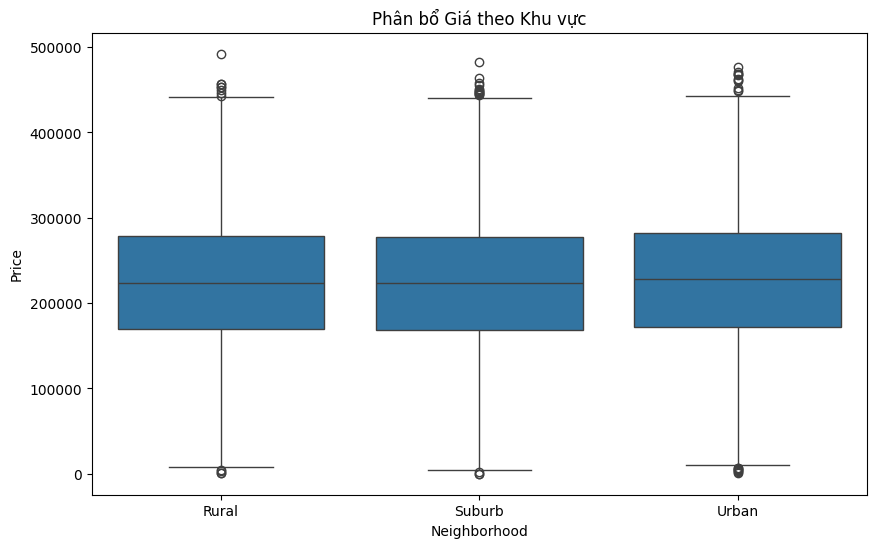

In [291]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Neighborhood', y='Price', data=df)
plt.title('Phân bổ Giá theo Khu vực')
plt.show()

Text(0.5, 1.0, 'Xu hướng Giá nhà trung bình qua các năm')

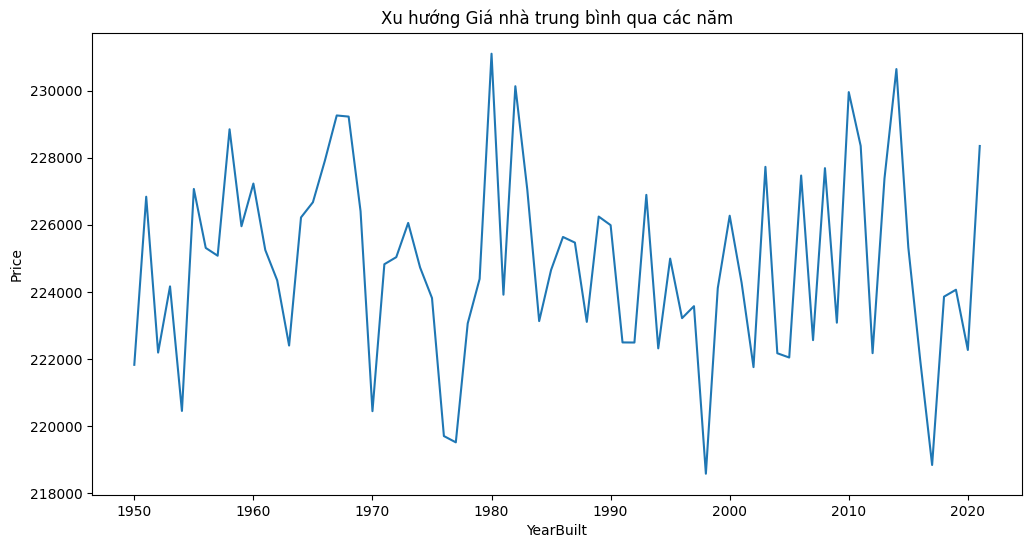

In [292]:
# Xu hướng giá theo năm xây dựng
plt.figure(figsize=(12, 6))
df_yearly = df.groupby('YearBuilt')['Price'].mean().reset_index()
sns.lineplot(x='YearBuilt', y='Price', data=df_yearly)
plt.title('Xu hướng Giá nhà trung bình qua các năm')

### Feature Engineering

In [293]:
cols_oh = ["Neighborhood"]

enc = OneHotEncoder(sparse_output=False)

X_encoded = enc.fit_transform(df[cols_oh])

encoded_cols = enc.get_feature_names_out(cols_oh)

df_encoded = pd.DataFrame(X_encoded, columns=encoded_cols, index=df.index)

df = pd.concat([df.drop(columns=cols_oh), df_encoded], axis=1)

In [294]:
df['TotalRooms'] = df['Bathrooms'] + df['Bedrooms']
df['SqftPerRoom'] = df['SquareFeet'] / df['TotalRooms']

current_year = 2026
df['HouseAge'] = current_year - df['YearBuilt']
df['IsNew'] = (df['YearBuilt'] > 2015).astype(int)

df['Sqft_Urban'] = df['SquareFeet'] * df['Neighborhood_Urban']
df['Sqft_Rural'] = df['SquareFeet'] * df['Neighborhood_Rural']
df['Sqft_Suburb'] = df['SquareFeet'] * df['Neighborhood_Suburb']

### Data Processing

In [ ]:
class MinMaxScaler:
    def __init__(self):
        self.min_ = None
        self.max_ = None
    
    def fit(self, X):
        X_arr = np.array(X)
        self.min_ = np.min(X_arr, axis=0)
        self.max_ = np.max(X_arr, axis=0)
        return self
    
    def transform(self, X):
        """
        Áp dụng công thức (X - Min) / (Max - Min)
        """
        X_array = np.array(X)
        # Công thức: (X - min) / (max - min)
        X_scaled = (X_array - self.min_) / (self.max_ - self.min_)
        return X_scaled

    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [296]:
df_cleaned = df[df['Price'] > 10000].copy()

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Ngưỡng dưới: {lower_bound:.2f}")
print(f"Ngưỡng trên: {upper_bound:.2f}")

df_cleaned = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]

print(f"Số lượng dòng ban đầu: {len(df)}")
print(f"Số lượng dòng sau khi làm sạch: {len(df_cleaned)}")
print(f"Đã loại bỏ: {len(df) - len(df_cleaned)} dòng outliers.")

df = df_cleaned.copy()

Ngưỡng dưới: 5829.21
Ngưỡng trên: 443500.28
Số lượng dòng ban đầu: 50000
Số lượng dòng sau khi làm sạch: 49955
Đã loại bỏ: 45 dòng outliers.


In [297]:
df.describe().round(1)

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price,Neighborhood_Rural,Neighborhood_Suburb,Neighborhood_Urban,TotalRooms,SqftPerRoom,HouseAge,IsNew,Sqft_Urban,Sqft_Rural,Sqft_Suburb
count,49955.0,49955.0,49955.0,49955.0,49955.0,49955.0,49955.0,49955.0,49955.0,49955.0,49955.0,49955.0,49955.0,49955.0,49955.0
mean,2006.1,3.5,2.0,1985.4,224764.8,0.3,0.3,0.3,5.5,392.7,40.6,0.1,669.8,667.7,668.7
std,575.2,1.1,0.8,20.7,75831.9,0.5,0.5,0.5,1.4,163.9,20.7,0.3,1005.9,1000.8,1000.3
min,1000.0,2.0,1.0,1950.0,6124.0,0.0,0.0,0.0,3.0,125.0,5.0,0.0,0.0,0.0,0.0
25%,1513.0,3.0,1.0,1967.0,169973.3,0.0,0.0,0.0,4.0,271.3,23.0,0.0,0.0,0.0,0.0
50%,2007.0,3.0,2.0,1985.0,225029.9,0.0,0.0,0.0,6.0,364.7,41.0,0.0,0.0,0.0,0.0
75%,2505.0,4.0,3.0,2003.0,279308.9,1.0,1.0,1.0,6.0,478.8,59.0,0.0,1521.0,1504.5,1514.0
max,2999.0,5.0,3.0,2021.0,443335.5,1.0,1.0,1.0,8.0,999.7,76.0,1.0,2999.0,2999.0,2999.0


In [298]:
features_cols_test = ['SquareFeet', 'TotalRooms', 'HouseAge', 'SqftPerRoom', 
                 'IsNew', 'Neighborhood_Suburb', 'Sqft_Suburb',
                'Sqft_Urban', 'Sqft_Rural', 'Neighborhood_Urban', 'Neighborhood_Rural']

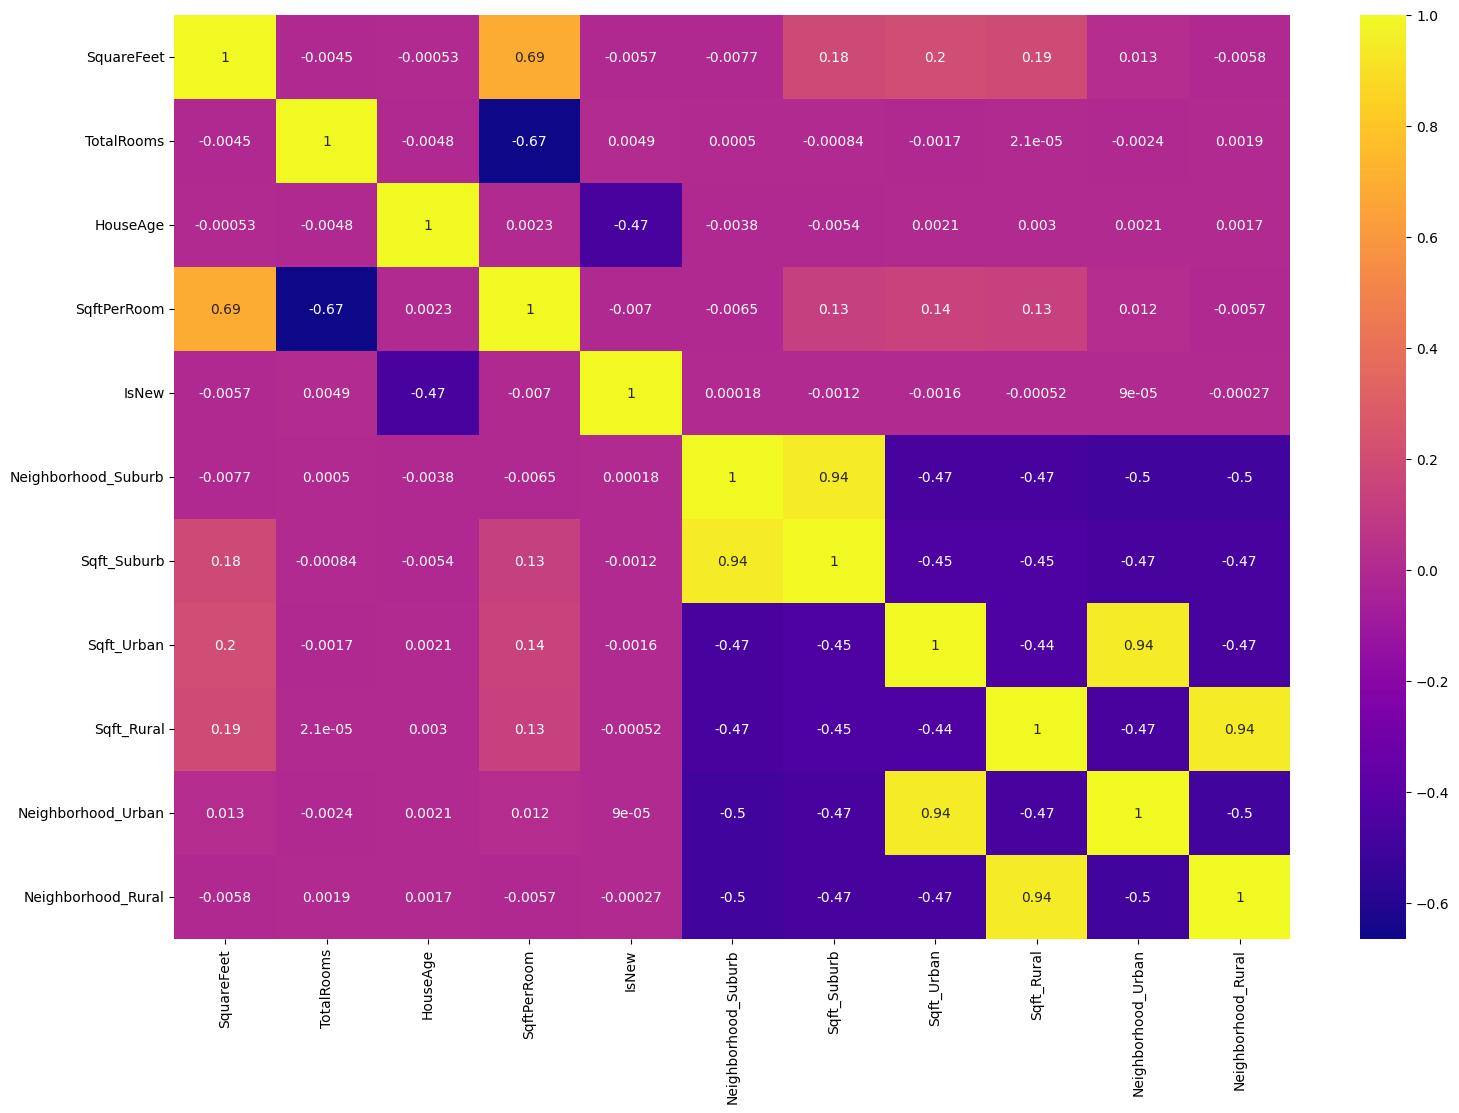

In [299]:
plt.figure(figsize=(18, 12))
sns.heatmap(df[features_cols_test].select_dtypes(include='number').corr(), annot=True, cmap='plasma')
plt.show()

In [300]:
features_cols = ['SquareFeet', 'TotalRooms', 'HouseAge', 'SqftPerRoom', 
                 'IsNew', 'Sqft_Suburb', 'Sqft_Urban', 'Sqft_Rural']

X = df[features_cols]
y = df['Price']

In [301]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


Cols = ['SquareFeet', 'TotalRooms', 'HouseAge', 'SqftPerRoom', 'Sqft_Suburb', 'Sqft_Urban', 'Sqft_Rural']

scaler = MinMaxScaler()

X_train[Cols] = scaler.fit_transform(X_train[Cols])
X_test[Cols] = scaler.transform(X_test[Cols])

In [302]:
X_train.describe().round(2)

,SquareFeet,TotalRooms,HouseAge,SqftPerRoom,IsNew,Sqft_Suburb,Sqft_Urban,Sqft_Rural
count,39964.00,39964.00,39964.00,39964.00,39964.00,39964.00,39964.00,39964.00
mean,0.50,0.50,0.50,0.31,0.08,0.22,0.22,0.22
std,0.29,0.28,0.29,0.19,0.27,0.33,0.34,0.33
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.26,0.20,0.25,0.17,0.00,0.00,0.00,0.00
50%,0.50,0.40,0.51,0.27,0.00,0.00,0.00,0.00
75%,0.75,0.60,0.76,0.40,0.00,0.51,0.51,0.50
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [303]:
X_train.shape

(39964, 8)

In [304]:
import numpy as np

def compute_mse(y, y_pred):
    return np.mean((y-y_pred) ** 2)

def compute_mae(y, y_pred):
    return np.mean(np.abs(y-y_pred))

def compute_mape(y, y_pred):
    return 100 * np.mean(np.abs(y-y_pred) / y)

def compute_r2(y, y_pred):
    ss_res = np.mean((y - y_pred) ** 2)
    ss_tot = np.mean((y - np.mean(y)) ** 2)
        
    return 1 - (ss_res / ss_tot)

def regression_report(y, y_pred):
    mae = compute_mae(y, y_pred)
    mse = compute_mse(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = compute_r2(y, y_pred)
    mape = compute_mape(y, y_pred)

    print("Regression Report")
    print("------------------")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    print(f"MAPE : {mape:.4f}")

In [305]:
import torch
import torch.nn as nn
import torch.optim as optim

class Model(nn.Module):
    def __init__(self, input_size):
        super(Model, self).__init__()
        
        self.main_structure = nn.Sequential(
            # Layer 1
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Layer 2
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            # Layer 3
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(),
            
            # Output Layer (Regression)
            nn.Linear(16, 1)
        )
        
    def forward(self, x):
        # Chỉ cần gọi main_structure, dữ liệu sẽ tự đi qua các lớp theo thứ tự
        return self.main_structure(x)

In [306]:
X_train_tensor = torch.FloatTensor(X_train.values)
X_test_tensor = torch.FloatTensor(X_test.values)

y_train_scaled = y_train.values / 1000
y_test_scaled = y_test.values / 1000

y_train_tensor = torch.FloatTensor(y_train_scaled).view(-1, 1)
y_test_tensor = torch.FloatTensor(y_test_scaled).view(-1, 1)

In [307]:
# Khởi tạo mô hình
input_dim = X_train.shape[1] # Số lượng cột đầu vào
model = Model(input_dim)

# Hàm mất mát cho phân loại nhị phân
criterion = nn.MSELoss()

# Bộ tối ưu hóa Adam
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)

# Vòng lặp huấn luyện
epochs = 1000
for epoch in range(epochs):
    model.train()
    
    # Forward pass: Dự đoán
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    # Backward pass: Tính toán đạo hàm và cập nhật trọng số
    optimizer.zero_grad() # Xóa gradient cũ
    loss.backward()       # Lan truyền ngược
    optimizer.step()      # Cập nhật weight
    
    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 51565.0312
Epoch [200/1000], Loss: 38265.6406
Epoch [300/1000], Loss: 21383.4746
Epoch [400/1000], Loss: 9242.8213
Epoch [500/1000], Loss: 3972.8633
Epoch [600/1000], Loss: 2673.4363
Epoch [700/1000], Loss: 2493.3032
Epoch [800/1000], Loss: 2473.7014
Epoch [900/1000], Loss: 2471.7317
Epoch [1000/1000], Loss: 2470.9490


In [308]:
model.eval() # Chuyển mô hình sang chế độ đánh giá

with torch.no_grad(): # Không tính đạo hàm để tiết kiệm bộ nhớ
    y_pred_scaled = model(X_test_tensor).numpy()
    
    y_pred = y_pred_scaled * 1000
    y_test = y_test_tensor.numpy() * 1000

regression_report(y_test, y_pred)

Regression Report
------------------
MAE  : 39936.9297
MSE  : 2482236160.0000
RMSE : 49822.0430
R2   : 0.5676
MAPE : 23.4812
